In [2]:
from ref import *
from read_complex_matrix import read_complex_matrix
matr = read_complex_matrix('ref_matrix.txt')
import timeit

In [3]:
q = dynamic_mesh_q(kmax, Ndots, gap)
x_crit, y_max, x_max, y_min, x_min  = reflectometry_trace(q, matr)

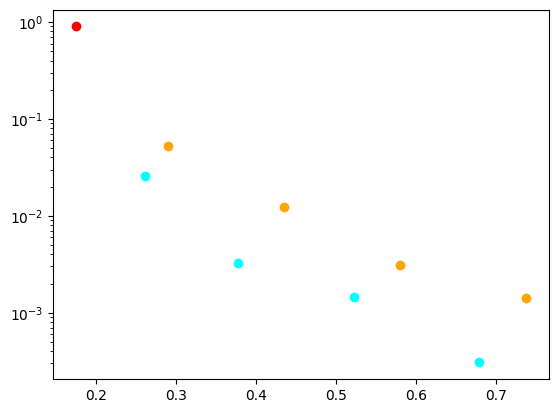

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

#ax.plot(q[0:len(y)]*1e-9, y)
ax.scatter(x_max*1e-9, y_max, color = 'orange')
ax.scatter(x_min*1e-9, y_min, color = 'cyan')
ax.scatter(x_crit*1e-9, 0.9, color = 'red')

ax.set_yscale('log')

plt.show()

In [5]:
class Comparator:
    def __init__(self, q, orig_matr):
        self.q = q
        self.original_trace = reflectometry_trace(q, orig_matr)
        
    def compare_trace(self, var_matr):
        crit1, r_max1, q_max1, r_min1, q_min1 = self.original_trace 
        crit2, r_max2, q_max2, r_min2, q_min2 = reflectometry_trace(self.q, var_matr)
        #print(var_matr)
        
        loss = (2*len(r_max1)*(crit1-crit2)/crit1)**2 + np.sum(((r_max1-r_max2)/r_max1)**2) + np.sum(((q_max1-q_max2)/q_max1)**2) + np.sum(((q_min1-q_min2)/q_min1)**2)
        
        return loss

# Вызываем compare много раз без повторной загрузки reference_points
loss_function = Comparator(q, matr)

In [6]:
all_bounds = np.array([[[1.0000e-09, 1.0000e-09], [0.0000e+00, 0.0000e+00],  [0.0000e+00, 0.0000e+00]],
                       [[1.0000e-08, 9.0000e-08], [8.0000e+14, 8.0000e+14],  [3.0000e-09, 5.0000e-09]],
                       [[1.0000e-08, 3.0000e-08], [-2.0000e+14, -2.0000e+14],[1.0000e-09, 9.0000e-09]],
                       [[1.0000e-09, 1.0000e-09], [2.0000e+14, 2.0000e+14],  [0.0000e+00, 0.0000e+00]]])

In [7]:
class varbounds:
    def __init__(self, bounds_tensor):
        self.bounds = bounds_tensor

    def objective_function(self, var_vector):
        matrixx = self.bounds[..., 0]
        matrixx[np.where(self.bounds[..., 0] != self.bounds[..., 1])] = var_vector
        return loss_function.compare_trace(matrixx)

objective_function = varbounds(all_bounds)

In [8]:
objective_function.objective_function(np.array([4.e-08, 3.e-09, 2.e-08, 3.e-09]))

np.float64(0.034118209103545655)

In [9]:
from scipy.optimize import differential_evolution as de
from scipy.optimize import minimize


# диапазон для шероховатостей и глубин (для двух поверхностных слоёв)
bounds = [[3.e-08, 5.e-08], [0, 8e-9], 
          [1.4e-8, 2.6e-8], [0, 8e-9]]

initial_guess = [3.1e-08, 1e-9,1.5e-8, 1e-9]

In [12]:
%%time

# Оптимизация с автоматическим численным градиентом вариант 1
result = minimize(
    objective_function.objective_function,
    initial_guess,
    method='L-BFGS-B',  
    bounds=bounds,
    options={
        'eps': 1e-15, # Шаг для численного градиента
        'maxfun': 1e+8,
        'ftol': 2e-19, 
        'gtol': 1e-24
    }  
)

CPU times: total: 719 ms
Wall time: 717 ms


In [13]:
result

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 4.254810254321881e-12
        x: [ 4.000e-08  4.000e-09  2.000e-08  2.000e-09]
      nit: 29
      jac: [-3.241e+02  1.003e+02  1.422e+02 -1.837e+02]
     nfev: 265
     njev: 53
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>